# Notebook de análisis — AstroBioSim

Corridas Montecarlo reproducibles de los tres entornos del estudio (**Tierra**,
**Marte**, **Encélado**) usando el orquestador `src/astrobiosim/simulation.py`
sobre los datasets reales de `data/processed/`.

**Qué hace este notebook:**

1. Carga los tres datasets análogos con los adaptadores de
   `astrobiosim.data.loaders` (Tierra: Valles de Fresno; Marte: Atacama
   CRC1211DB; Encélado: ventilas hidrotermales).
2. Arma un `ModoAnalogico` por entorno (`astrobiosim.modes.analog`), que
   reutiliza el modelo espacial de cada `PlanetaSubsuelo` (banda de profundidad
   en Marte, fumarolas en Encélado) para expandir cada fila diaria del dataset a
   un `CampoAmbiental` de grilla completa (ADR-0017).
3. Corre un experimento Montecarlo (`simular_montecarlo`) de 20 réplicas por
   entorno, con **semillas explícitas**, para separar la señal de la dinámica
   ambiental del ruido puramente estocástico del autómata.
4. Grafica las tres fracciones poblacionales (`ACTIVA`, `LATENTE`, `MUERTA`)
   como media ± desviación estándar a lo largo del tiempo, para cada entorno.
5. Interpreta biológicamente los resultados de cada entorno (celdas Markdown).

**Asignación especie ↔ entorno** (ADR-0001/ADR-0011, validada en
`tests/integration/test_especie_en_su_entorno.py`):

| Entorno | Especie | Motivo |
|---|---|---|
| Tierra (control) | `EColi` | mesófila, sensible al UV, control de referencia |
| Marte (Atacama) | `DRadiodurans` | radiorresistente y anhidrobiótica |
| Encélado (subglacial) | `MBurtonii` | metanógena psicrotolerante, no anhidrobiótica |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from astrobiosim.core.microorganism import (
    ACTIVA,
    LATENTE,
    MUERTA,
    DRadiodurans,
    EColi,
    MBurtonii,
)
from astrobiosim.data.loaders import cargar_atacama, cargar_control_tierra, cargar_ventilas
from astrobiosim.data.resampling import Entorno
from astrobiosim.modes.analog import ModoAnalogico
from astrobiosim.simulation import ResultadoMontecarlo, sembrar_estado, simular_montecarlo

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

## Configuración del experimento

Rutas a los datasets reales de `data/processed/` (con resolución robusta: el
notebook corre igual desde `notebooks/` con Jupyter que desde la raíz del repo
con `nbconvert`).

In [2]:
def _localizar_data_dir() -> Path:
    for candidato in (Path("data/processed"), Path("../data/processed")):
        if candidato.exists():
            return candidato.resolve()
    raise FileNotFoundError(
        "No se encontró data/processed/ ni desde el repo ni desde notebooks/"
    )


DATA_DIR = _localizar_data_dir()
RUTA_TIERRA = DATA_DIR / "datos_tierra_control_2025.csv"
RUTA_MARTE = DATA_DIR / "datos_atacama_2025_EXTREMOS_REALES.csv"
RUTA_ENCELADO = DATA_DIR / "datos_ventilas_2025_procesados.csv"
print(f"data/processed/ localizado en: .../{DATA_DIR.parent.name}/{DATA_DIR.name}")

data/processed/ localizado en: .../data/processed


## Diseño del experimento Montecarlo

- **Réplicas:** 20, con **semillas explícitas** `[42, 43, …, 61]` — una lista
  concreta y auditable (`simular_montecarlo(..., semillas=SEMILLAS)`), no solo
  una semilla base + contador.
- **Duración:** cada réplica corre el año completo del dataset (365 días = 365
  ticks; `n_iteraciones=None` agota el `ModoAnalogico` — ver
  `simulation.py::simular`).
- **Estado inicial:** el mismo para las 20 réplicas y los 3 entornos
  (`sembrar_estado` con semilla fija `0`, 15 % de celdas `ACTIVA` dispersas al
  azar), para que la dispersión entre réplicas mida solo la dinámica
  estocástica del autómata y del ambiente (p. ej. el ruido espacial de `A_w` en
  Marte), no la variabilidad del arranque.
- **Grilla:** 30×30 (en vez del default 50×50 del motor) — reduce el costo de
  3 entornos × 20 réplicas × 365 ticks sin tocar ningún umbral ni la física del
  modelo: todo el autómata es vectorizado por celda, independiente de `M×N`.
- **Reproducibilidad:** repetir esta notebook con las mismas `SEMILLAS` da
  exactamente la misma `media`/`desviacion` (mismo mecanismo que valida
  `tests/integration/test_montecarlo.py::test_lista_explicita_de_semillas_reproducible`);
  se verifica explícitamente más abajo.

In [3]:
SHAPE = (30, 30)  # (M, N) de la grilla
SEMILLAS = list(range(42, 62))  # 20 semillas explícitas y reproducibles
FRACCION_ACTIVA_INICIAL = 0.15
SEMILLA_ESTADO_INICIAL = 0  # misma grilla de arranque en los 3 entornos

ESTADO_INICIAL = sembrar_estado(
    SHAPE,
    rng=np.random.default_rng(SEMILLA_ESTADO_INICIAL),
    fraccion_activa=FRACCION_ACTIVA_INICIAL,
    patron="uniforme",
)
print(f"Semillas ({len(SEMILLAS)}): {SEMILLAS}")
print(f"Fracción ACTIVA en t=0: {(ESTADO_INICIAL == ACTIVA).mean():.3f}")

Semillas (20): [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]
Fracción ACTIVA en t=0: 0.130


## Carga de los datasets reales

Un adaptador por entorno (`astrobiosim.data.loaders`); cada uno cae a un
fallback sintético si el CSV no existe, pero acá los tres archivos están en
`data/processed/`, así que se usa el dato real 2025 tal cual.

In [4]:
df_tierra = cargar_control_tierra(str(RUTA_TIERRA))
df_marte = cargar_atacama(str(RUTA_MARTE))
df_encelado = cargar_ventilas(str(RUTA_ENCELADO))

for nombre, df in [("Tierra", df_tierra), ("Marte", df_marte), ("Encélado", df_encelado)]:
    assert len(df) == 365, f"{nombre}: se esperaban 365 filas, hay {len(df)}"
    print(f"{nombre}: {len(df)} filas · columnas {list(df.columns)}")

Tierra: 365 filas · columnas ['t', 'temperature', 'a_w', 'radiation']
Marte: 365 filas · columnas ['t', 'temperature', 'a_w', 'radiation', 'temperature_min', 'temperature_max']
Encélado: 365 filas · columnas ['t', 'temperature', 'a_w', 'radiation']


## Corridas Montecarlo

`correr_montecarlo` arma, por réplica, un `ModoAnalogico` **fresco** con su
propio `rng` (factory, para no filtrar estado entre réplicas — ver
`simular_montecarlo`) y corre el año completo del dataset con la especie
asignada a ese entorno.

In [5]:
def correr_montecarlo(df: pd.DataFrame, entorno: Entorno, especie) -> ResultadoMontecarlo:
    '''Corre el experimento Montecarlo (20 réplicas, semillas explícitas) de un entorno.'''

    def construir_modo(rng: np.random.Generator) -> ModoAnalogico:
        return ModoAnalogico(df, entorno, SHAPE, rng=rng)

    return simular_montecarlo(
        construir_modo,
        especie,
        ESTADO_INICIAL,
        semillas=SEMILLAS,
        n_iteraciones=None,  # agota el año completo del dataset (365 ticks)
    )

In [6]:
resultado_tierra = correr_montecarlo(df_tierra, Entorno.TIERRA, EColi())
resultado_marte = correr_montecarlo(df_marte, Entorno.MARTE, DRadiodurans())
resultado_encelado = correr_montecarlo(df_encelado, Entorno.ENCELADO, MBurtonii())

for nombre, res in [
    ("Tierra", resultado_tierra),
    ("Marte", resultado_marte),
    ("Encélado", resultado_encelado),
]:
    print(f"{nombre}: {res.n_corridas} réplicas · {len(res)} ticks (incl. t=0)")

Tierra: 20 réplicas · 366 ticks (incl. t=0)
Marte: 20 réplicas · 366 ticks (incl. t=0)
Encélado: 20 réplicas · 366 ticks (incl. t=0)


### Verificación de reproducibilidad

Repetimos la corrida de Marte con las mismas semillas explícitas: el agregado
(media y desviación por tick) debe salir **bit a bit idéntico**.

In [7]:
_verificacion_marte = correr_montecarlo(df_marte, Entorno.MARTE, DRadiodurans())
np.testing.assert_array_equal(resultado_marte.media, _verificacion_marte.media)
np.testing.assert_array_equal(resultado_marte.desviacion, _verificacion_marte.desviacion)
print("Reproducibilidad verificada: misma media y desviación con las mismas semillas explícitas.")

Reproducibilidad verificada: misma media y desviación con las mismas semillas explícitas.


## Curvas poblacionales: fracción media ± σ por estado

Colores fijos y consistentes en las tres figuras: **verde** = `ACTIVA` (crece),
**ámbar** = `LATENTE` (viva, sin reproducirse) y **rojo** = `MUERTA` (terminal,
ADR-0012). La banda sombreada es ±1 desviación estándar muestral entre las 20
réplicas.

In [8]:
COLOR_ESTADO = {
    ACTIVA: "#008300",  # verde: crecimiento activo
    LATENTE: "#eda100",  # ámbar: viva, sin reproducirse
    MUERTA: "#e34948",  # rojo: terminal (ADR-0012, absorbente)
}
NOMBRE_ESTADO = {ACTIVA: "ACTIVA", LATENTE: "LATENTE", MUERTA: "MUERTA"}


def graficar_montecarlo(resultado: ResultadoMontecarlo, titulo: str, ax=None):
    '''Curvas de fracción media ± 1 sigma por estado, a lo largo del tiempo.'''
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4.5))
    tiempo = np.arange(len(resultado))
    for estado in (ACTIVA, LATENTE, MUERTA):
        media, sd = resultado.curva(estado)
        color = COLOR_ESTADO[estado]
        ax.plot(tiempo, media, color=color, linewidth=2, label=NOMBRE_ESTADO[estado])
        ax.fill_between(
            tiempo,
            np.clip(media - sd, 0.0, 1.0),
            np.clip(media + sd, 0.0, 1.0),
            color=color,
            alpha=0.18,
            linewidth=0,
        )
    ax.set_xlim(tiempo[0], tiempo[-1])
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel("Fracción de celdas")
    ax.set_title(titulo)
    ax.grid(True, color="#e1e0d9", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, loc="center right")
    return ax

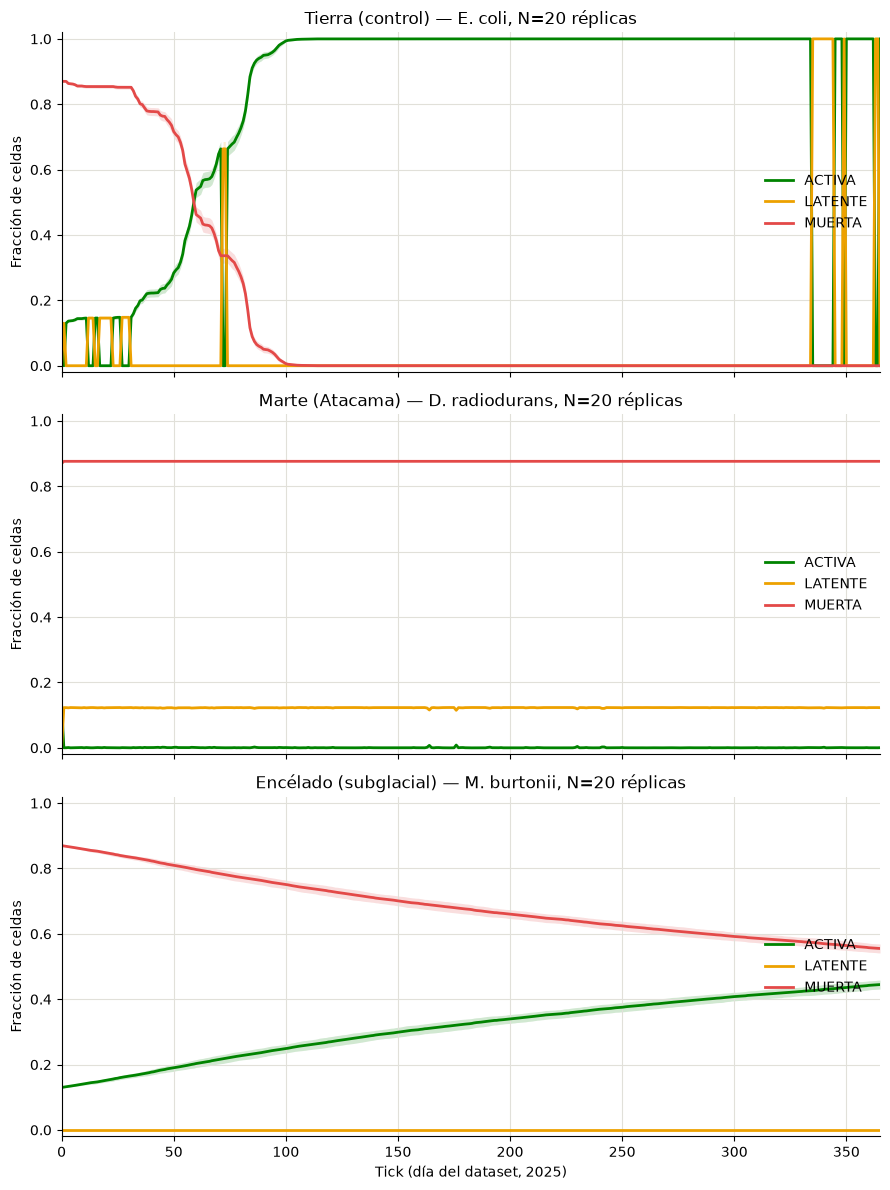

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(9, 12), sharex=True)
graficar_montecarlo(resultado_tierra, "Tierra (control) — E. coli, N=20 réplicas", ax=axes[0])
graficar_montecarlo(resultado_marte, "Marte (Atacama) — D. radiodurans, N=20 réplicas", ax=axes[1])
graficar_montecarlo(resultado_encelado, "Encélado (subglacial) — M. burtonii, N=20 réplicas", ax=axes[2])
axes[-1].set_xlabel("Tick (día del dataset, 2025)")
fig.tight_layout()
plt.show()

## Resumen numérico: t=0 vs. día 365

`activa_max_anual` es el **máximo** que alcanzó la fracción `ACTIVA` en
cualquier momento del año (no solo al final) — separa "la población nunca
volvió a crecer" de "creció y después colapsó".

In [10]:
def resumen(resultado: ResultadoMontecarlo, nombre: str) -> dict:
    m0 = resultado.media[0]
    mf = resultado.media[-1]
    sf = resultado.desviacion[-1]
    activa_media, _ = resultado.curva(ACTIVA)
    return {
        "entorno": nombre,
        "activa_t0": m0[ACTIVA],
        "activa_final": mf[ACTIVA],
        "activa_final_sd": sf[ACTIVA],
        "activa_max_anual": activa_media.max(),
        "latente_final": mf[LATENTE],
        "muerta_t0": m0[MUERTA],
        "muerta_final": mf[MUERTA],
    }


tabla_resumen = pd.DataFrame(
    [
        resumen(resultado_tierra, "Tierra"),
        resumen(resultado_marte, "Marte"),
        resumen(resultado_encelado, "Encélado"),
    ]
).set_index("entorno")
tabla_resumen.round(4)

,activa_t0,activa_final,activa_final_sd,activa_max_anual,latente_final,muerta_t0,muerta_final
entorno,,,,,,,
Tierra,0.13,1.0000,0.0000,1.0000,0.0000,0.87,0.0000
Marte,0.13,0.0004,0.0008,0.1300,0.1229,0.87,0.8766
Encélado,0.13,0.4447,0.0137,0.4447,0.0000,0.87,0.5553


## Lectura biológica por entorno

### 🌍 Tierra (control): sobresaltos invernales reales y colonización total

En el Modo Sandbox el subsuelo de control es un campo estático a 19,8 °C. Pero
acá corremos el **Modo Analógico** con el dato diario *real* de Fresno 2025, y
ese dato sí tiene estación: 29 de los 365 días —agrupados en enero y en
diciembre, el invierno del hemisferio norte— bajan de los 7,5 °C que necesita
*E. coli* para crecer (`t_min`), aunque nunca cerca de su límite de
supervivencia (`t_sup_min = -20 °C`). El campo de Tierra es espacialmente
**uniforme** (sin ruido por celda, a diferencia de Marte), así que cada uno de
esos días fríos hace que **toda** la población ya colonizada pase de golpe de
`ACTIVA` a `LATENTE` —nunca a `MUERTA`— y vuelva a `ACTIVA` al día siguiente en
cuanto sube la temperatura. Esa es la causa exacta de las franjas verde/ámbar
alternadas que se ven entre los días 0–90 (enero–marzo) y de nuevo cerca del
día 335–365 (diciembre): no es ruido de muestreo, es la especie respondiendo
día a día a un dato ambiental real. Entre esos sobresaltos, `MUERTA` cae de
forma monótona: es la colonización avanzando sobre sustrato virgen, no
organismos muriendo.

Hacia el día ~100, con el invierno atrás, la colonización llega al 100 % y se
sostiene el resto del año (los sobresaltos de diciembre ya no alcanzan a
revertirla). El límite no es ambiental sino de **velocidad de colonización**:
`E. coli` tiene el `mu_opt` más alto de las tres especies (2,1 h⁻¹), así que el
frente de reproducción por contacto llena la grilla 30×30 bastante antes de
que termine el año. Este resultado —una especie de referencia que tolera el
invierno real sin extinguirse y termina colonizando toda la grilla— es el que
valida que el resto del pipeline (motor ambiental + motor biológico +
autómata) funciona: si el control no prosperara, no habría con qué comparar
Marte y Encélado.

### 🔴 Marte (Atacama): extinción en bulk — el resultado esperado (ADR-0015)

`D. radiodurans` necesita `A_w ≥ 0,90` para **crecer** (su límite de
metabolismo activo), pero la media diaria real de Atacama 2025 es de solo
≈0,19 (con un ruido espacial de `σ ≈ 0,26` por celda). Eso deja la probabilidad
de que una celda cruce el umbral de crecimiento en un tick dado en apenas
~0,2–1 %: durante **todo el año**, la fracción `ACTIVA` nunca supera su valor
de siembra inicial (13 %) — no hay un solo evento de recolonización neta.

Lo que sí ocurre es la transición **`ACTIVA → LATENTE`** (anhidrobiosis, no
muerte): al día 365 la población queda en ~87,7 % `MUERTA`, ~12,3 % `LATENTE`
y ~0,04 % `ACTIVA`, con una desviación estándar minúscula entre réplicas — es
un colapso *determinista* del régimen anual medio, no una fluctuación de
muestreo. El leve aumento de `MUERTA` respecto al 87,0 % inicial (unas pocas
celdas más) es consistente con la delgada capa superficial expuesta a UV
pleno, la única fuente de mortalidad real en este entorno (el resto del
subsuelo es térmicamente inocuo para la especie).

Es exactamente la lectura que anticipa ADR-0015: en el régimen **medio** anual
de Atacama, sin microrefugios húmedos transitorios, la extinción en bulk es el
resultado *correcto*, no un bug de calibración. Esta corrida (sin eventos
estocásticos) es la línea de base que motiva la tarjeta "Barrido: umbral
crítico de microrefugios" — cuánta frecuencia/magnitud de `SalmueraDelicuescente`
hace falta para revertir esta historia.

### 🧊 Encélado (subglacial): coloniza, pero no le alcanza el año

El océano subglacial es el entorno menos extremo de los tres para su especie:
`M. burtonii` crece en **toda** la grilla en `t=0` (temperatura ~2,4 °C de
fondo más los núcleos de fumarola a ~27,4 °C, ambos dentro de su rango
`t_min=-2,5 / t_max=29,5`; `A_w≈0,98` muy por encima de su `a_w_min=0,95`). No
hay banda estéril como en Marte ni umbral de agua inalcanzable.

Aun así, la fracción `ACTIVA` solo llega a **44,5 %** hacia el día 365, subiendo
de forma monótona y sin pasar nunca por `LATENTE` (0 % durante todo el año):
como `M. burtonii` no es anhidrobiótica (`a_w_sup_min = 0,80`, alto), una celda
o crece o muere, sin el colchón de dormancia que sí tiene `D. radiodurans`. El
55,5 % que queda en `MUERTA` al final del año no es un colapso ambiental —
`M. burtonii` tiene el `mu_opt` más bajo de las tres especies (0,069 h⁻¹, ~30×
más lento que *E. coli*) — es sustrato que el frente de colonización por
contacto todavía no alcanzó: recordar que el estado `MUERTA` inicial (celdas no
sembradas) representa sustrato **aún no colonizado**, no organismos muertos;
su ocupación por un vecino `ACTIVA` es colonización (ADR-0012), no
resurrección. Con más ticks (o una grilla más chica), cabría esperar que
Encélado termine, como Tierra, en 100 % `ACTIVA` — es una cuestión de tiempo
de difusión, no de habitabilidad.

### Comparación de las tres dinámicas

| Entorno | Especie | Factor limitante | Desenlace a 365 días |
|---|---|---|---|
| Tierra | *E. coli* | velocidad de colonización (frenada por sobresaltos invernales reales, nunca letales) | colonización total (100 % ACTIVA) |
| Marte | *D. radiodurans* | disponibilidad de agua (`A_w≥0,90` casi nunca) | extinción en bulk, resto LATENTE |
| Encélado | *M. burtonii* | velocidad de colonización (`mu_opt` bajo) | colonización parcial y creciente (44,5 %) |

La comparación deja un mensaje claro: **no alcanza con mirar la fracción viva
final** para juzgar la habitabilidad de un entorno. Marte y Encélado terminan
con una mayoría `MUERTA`, pero por razones opuestas — uno porque el ambiente
lo impide activamente (y solo un microrefugio transitorio podría revertirlo),
el otro porque simplemente hace falta más tiempo (o una grilla más chica) para
que la colonización llegue a todas partes.

---
**Criterios de aceptación cubiertos** (tarjeta *Notebook de análisis*,
`docs/tablero.md`):

- ✅ Corre de punta a punta usando `simulation.py` (`simular_montecarlo`,
  `sembrar_estado`).
- ✅ Grafica las tres fracciones (`ACTIVA`/`LATENTE`/`MUERTA`) media ± σ vs.
  tiempo para Tierra/Marte/Encélado.
- ✅ Resultados reproducibles con semillas explícitas (`SEMILLAS`), verificado
  explícitamente arriba.
- ✅ Lectura biológica de cada entorno documentada en las celdas Markdown.